# 1D harmonic oscillator physics-informed neural network (PINN) by Gabriel Milanez Cavalheri

This notebook contains based on the blog post ["So, what is a physics-informed neural network?"](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/). 


## Problem overview

The example problem we solve here is the 1D simple harmonic oscillator:
$$
m \dfrac{d^2 x}{d t^2} + kx = 0~,
$$

The analitical solution is:

$$
x(t) = A \sin(\omega_0 t - \delta)
$$

The solution can be found in the book: Thornton, Stephen T., and Jerry Marion. Classical dynamics of particles and systems. MTM, 2019.

## Workflow overview

>First we will train a standard neural network to interpolate a small part of the solution, using some observed training points from the solution.

>Next, we will train a PINN to extrapolate the full solution outside of these training points by penalising the underlying differential equation in its loss function.



In [1]:
from PIL import Image

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
def creating_csv_file(folder_path, file_name, arqs, loss_data):
    
    
    if type(arqs) == list:
        dict_data = dict(zip(arqs, loss_data))
    else:
        dict_data = {arqs : loss_data}    
    
    
    print(type(loss_data))
    print(loss_data)
    print(dict_data)
    
    file_ready = pd.DataFrame(data=dict_data)
    path = f'{folder_path}/{file_name}.csv'
    file_ready.to_csv(path, index=False, sep=',')

def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)
    
def oscillator(d, w0, x):
    """Defines the analytical solution to the 1D underdamped harmonic oscillator problem. 
    Equations taken from: https://beltoforion.de/en/harmonic_oscillator/"""
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*x)
    sin = torch.sin(phi+w*x)
    exp = torch.exp(-d*x)
    y  = exp*2*A*cos
    return y

def simple_oscillator(w0, x, A, delta):
    y = A * torch.sin(w0 * x - delta)
    return y

class FCN(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x
    
# New class for the Discovery PINN in development
class FCN_disc(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
        self.k = nn.Parameter(data=torch.tensor([0.]))
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x
    
def eval_GA(n_arq, ini_epoch, n_hidden, n_layers, w0, x_data, y_data, x_physics, folder_path):
    # Making the initialization and fitness evaluation of the population
    k = w0**2
    fit_eva = []
    list_n_hidden = np.arange(1, n_hidden+1)
    list_n_layers = np.arange(2, n_layers+1)
    
    # Making the two list to transform into a dictionary to export into csv
    
    arqs = []
    losses = []
    
    for i in range(1, n_arq+1):
        torch.manual_seed(123)
        
        c_n_hidden = int(np.random.choice(list_n_hidden))
        c_n_layers = int(np.random.choice(list_n_layers))
        
        loss_ind = []
        arq = f"layers: {c_n_layers}, Hidden: {c_n_hidden}"
        arqs.append(arq)
        
        model = FCN(1, 1, c_n_hidden, c_n_layers)
        optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
        loss1_list = []
        loss2_list = []
        loss_t_list = []
        # Choosing 5% of the total epochs ini_epoch = 1000
        for i in range(ini_epoch):
            optimizer.zero_grad()
            
            # compute the "data loss"
            yh = model(x_data)
            loss1 = torch.mean((yh-y_data)**2)# use mean squared error
            
            # compute the "physics loss"
            yhp = model(x_physics)
            dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
            dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
            physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
            loss2 = (1e-4)*torch.mean(physics**2)
            
            # backpropagate joint loss
            loss1_list.append(loss1.detach())
            loss2_list.append(loss2.detach())
            loss = loss1 + loss2 # add two loss terms together
            loss_t_list.append(loss.detach())
            
            
            loss_ind.append(loss.detach())
            
            loss.backward()
            optimizer.step()
            
        losses.append(loss_ind)   
        
        fit_eva.append([loss_t_list[-1], c_n_hidden, c_n_layers])
    
    # Saving in csv
    creating_csv_file(folder_path=folder_path, file_name='Evaluation', arqs=arqs, loss_data=losses)
    
        
    fit_eva.sort()
    
    return fit_eva[0:5]
        

def muta_GA(mut_epoch, fit_eva, w0, x_data, y_data, x_physics, folder_path):
    # Making the initialization and fitness evaluation of the population
    k = w0**2
    termi = []
    new_conf = []

    arqs = []
    losses = []    
    
    
    # Mutation
    for m in range(0, len(fit_eva)):
        # Select only the configuration
        norma_conf = fit_eva[m][1:3]
        
        # Choose the mutation and add to the normal configuration, creating a new configuration
        muta_hidden = norma_conf[0] + np.random.choice(a=[0,1,2])
        muta_layer = norma_conf[1] + np.random.choice(a=[0,1])
        

        
        # join the layer and the hidden
        muta_conf = [muta_hidden, muta_layer]
        
        # Adding the two configurations to the new pool
        new_conf.append(norma_conf)
        new_conf.append(muta_conf)
    
    # Evaluating again with the new pool
    for i in range(0, len(new_conf)):
        
        torch.manual_seed(123)
        
        c_n_hidden = new_conf[i][0]
        c_n_layers = new_conf[i][1]
        
        loss_ind = []
        arq = f"layers: {c_n_layers}, Hidden: {c_n_hidden}"
        arqs.append(arq)
        
        model = FCN(1, 1, c_n_hidden, c_n_layers)
        optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
        loss1_list = []
        loss2_list = []
        loss_t_list = []
        # Choosing 5% of the total epochs ini_epoch = 1000
        for i in range(mut_epoch):
            optimizer.zero_grad()
            
            # compute the "data loss"
            yh = model(x_data)
            loss1 = torch.mean((yh-y_data)**2)# use mean squared error
            
            # compute the "physics loss"
            yhp = model(x_physics)
            dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
            dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
            physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
            loss2 = (1e-4)*torch.mean(physics**2)
            
            # backpropagate joint loss
            loss1_list.append(loss1.detach())
            loss2_list.append(loss2.detach())
            loss = loss1 + loss2 # add two loss terms together
            loss_t_list.append(loss.detach())

            loss_ind.append(loss.detach())
                   

            loss.backward()
            optimizer.step()
            
        losses.append(loss_ind)
        
        termi.append([loss_t_list[-1], c_n_hidden, c_n_layers])
        
        
    creating_csv_file(folder_path=folder_path, file_name='Mutation', arqs=arqs, loss_data=losses)
       
    termi.sort()
    
    return termi[0]


def neural_evolution(n_arq, ini_epoch, mut_epoch, n_hidden, n_layers, w0, x_data, y_data, folder_path):
    x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain
    
    fit_eva = eval_GA(n_arq, ini_epoch, n_hidden, n_layers, w0, x_data, y_data, x_physics, folder_path)
    
    print("The 5 best among the population")
    for i in fit_eva:
        print(f"MSE: {i[0]}, neurons in it layer: {i[1]}, number of hidden layers {i[2]}")
    
    result_mut = muta_GA(mut_epoch, fit_eva, w0, x_data, y_data, x_physics, folder_path)
    
    print("The best configuration")
    print(f"MSE: {result_mut[0]}, neurons in it layer: {result_mut[1]}, number of layers {result_mut[2]}")
    
    return result_mut[1:3]
    

## Generate training data

> First, we generate some training data from a small part of the true analytical solution.

For this problem, we use $A=1$, $\delta=0$,  $\omega_0=20$, and try to learn the solution over the domain $x\in [0,1]$.

torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])


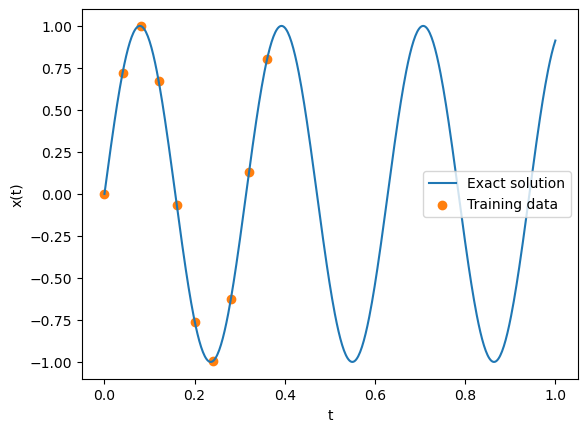

In [3]:
A, w0, delta = 1, 20, 0

# get the analytical solution over the full domain
x = torch.linspace(0,1,500).view(-1,1)
y = simple_oscillator(w0, x, A, delta).view(-1,1)
print(x.shape, y.shape)

# slice out a small number of points from the domain
x_data = x[0:200:20]
y_data = y[0:200:20]
print(x_data.shape, y_data.shape)

plt.figure()
plt.plot(x, y, label="Exact solution")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend(loc=5)
plt.ylabel("x(t)")
plt.xlabel("t")
plt.show()

## Normal neural network

> Next, we train a standard neural network (fully connected network) to fit these training points.

>We find that the network is able to fit the solution very closely in the vicinity of the training points, but does not learn an accurate solution outside of them.

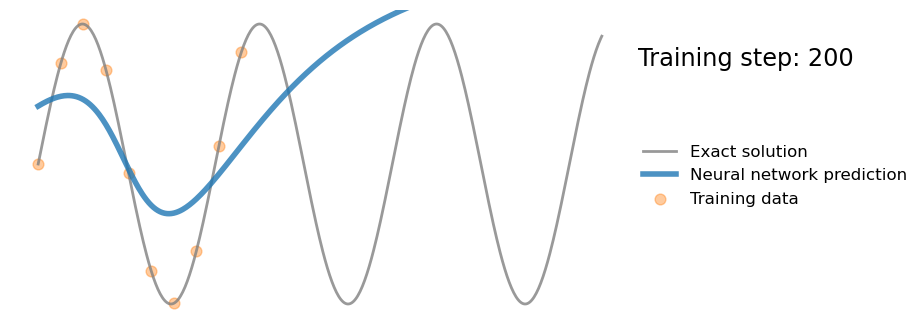

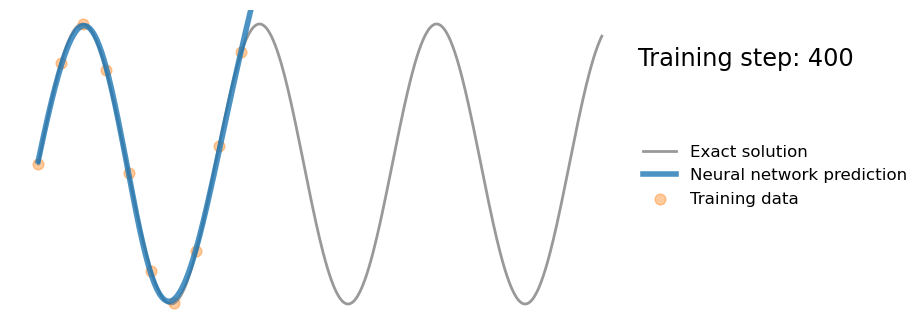

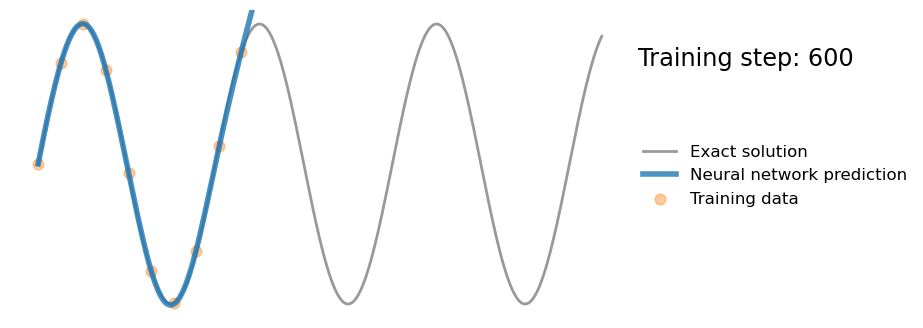

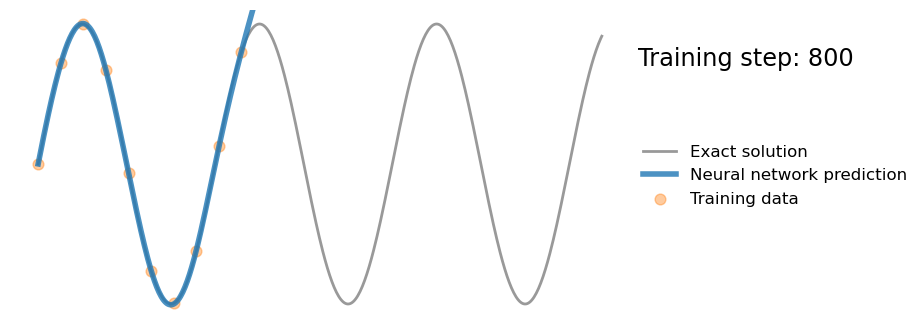

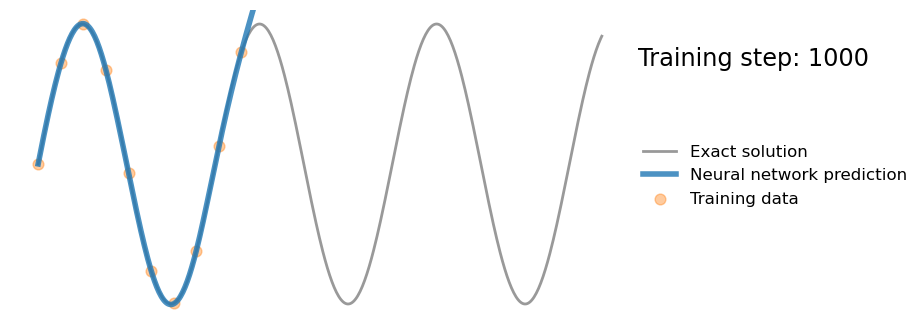

In [5]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4, 
                    label='Physics loss training locations')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05, 1.05)
    plt.ylim(-1.1, 1.1)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")
    
    
# train standard neural network to fit training data
torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
loss_p_list = []
files = []
for i in range(1000):
    optimizer.zero_grad()
    yh = model(x_data)
    loss = torch.mean((yh-y_data)**2)# use mean squared error
    loss_p_list.append(loss.detach())
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 10 == 0: 
        
        yh = model(x).detach()
        
        plot_result(x,y,x_data,y_data,yh)
        
        file = "plots/nn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
    
        if (i+1) % 200 == 0: plt.show()
        else: plt.close("all")
            
save_gif_PIL("nn.gif", files, fps=20, loop=0)

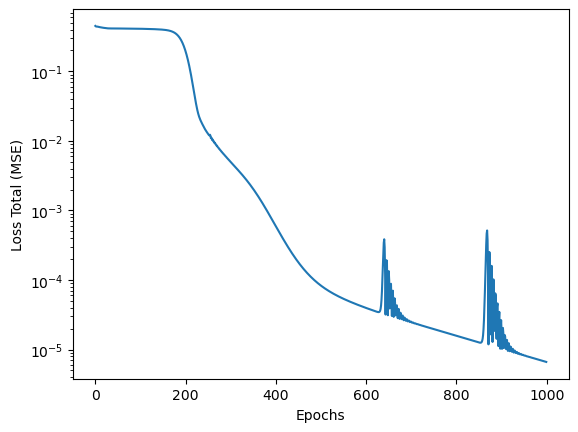

In [6]:
plt.plot(loss_p_list)
plt.ylabel("Loss Total (MSE)")
plt.xlabel("Epochs")
plt.yscale('log')

## PINN

> Finally, we add the underlying differential equation ("physics loss") to the loss function. 

The physics loss aims to ensure that the learned solution is consistent with the underlying differential equation. This is done by penalising the residual of the differential equation over a set of locations sampled from the domain.

Here we evaluate the physics loss at 30 points uniformly spaced over the problem domain $([0,1])$. We can calculate the derivatives of the network solution with respect to its input variable at these points using `pytorch`'s autodifferentiation features, and can then easily compute the residual of the differential equation using these quantities.

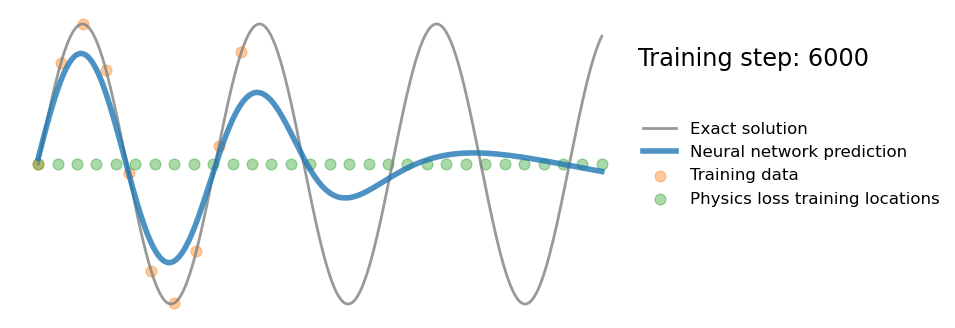

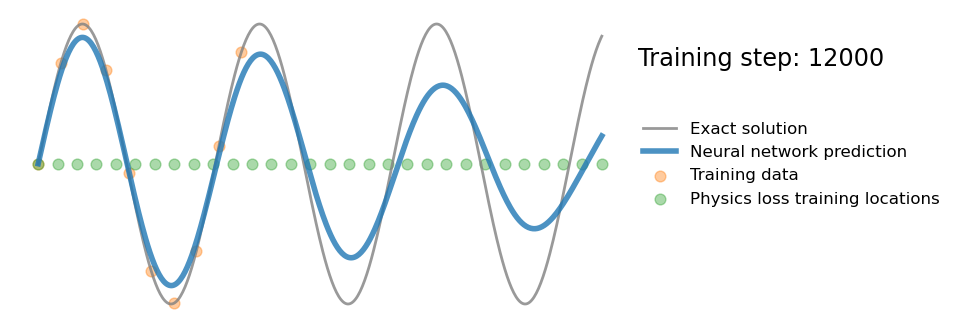

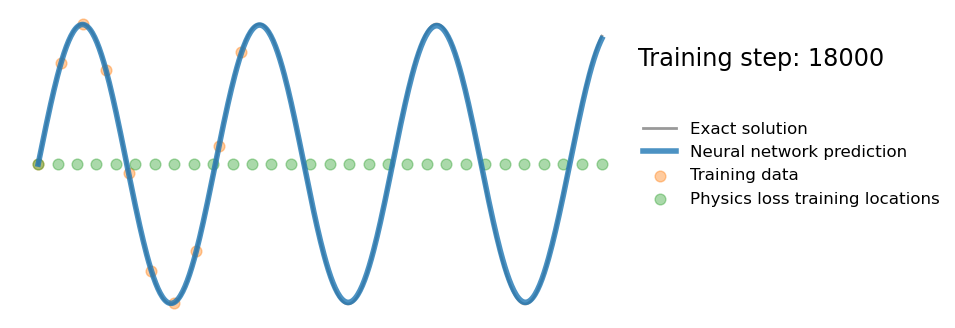

In [ ]:
x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain
k = w0**2

torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
files = []
loss1_list = []
loss2_list = []
loss_t_list = []
for i in range(20000):
    optimizer.zero_grad()
    
    # compute the "data loss"
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)# use mean squared error
    
    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
    loss2 = (1e-4)*torch.mean(physics**2)
    
    # backpropagate joint loss
    loss1_list.append(loss1.detach())
    loss2_list.append(loss2.detach())
    loss = loss1 + loss2# add two loss terms together
    loss_t_list.append(loss.detach())
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 150 == 0: 
        
        yh = model(x).detach()
        xp = x_physics.detach()
        
        plot_result(x,y,x_data,y_data,yh,xp)
        
        file = "plots/pinn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        
        if (i+1) % 6000 == 0: plt.show()
        else: plt.close("all")
            
save_gif_PIL("pinn.gif", files, fps=20, loop=0)

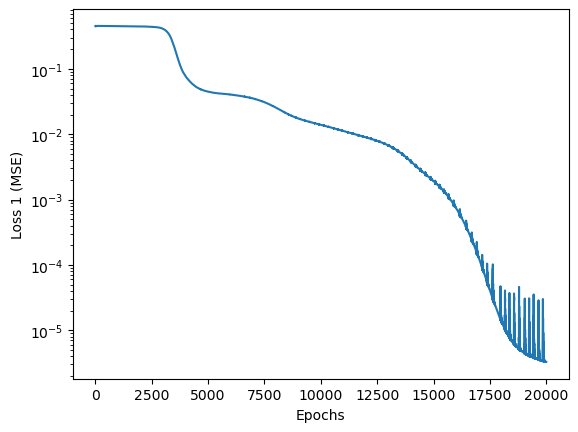

In [8]:
plt.plot(loss1_list)
plt.ylabel("Loss 1 (MSE)")
plt.xlabel("Epochs")
plt.yscale('log')

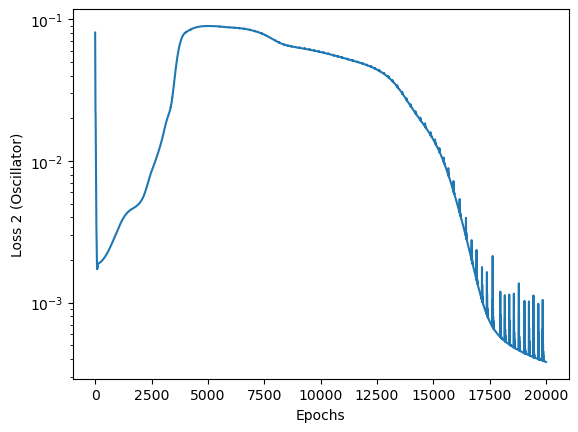

In [9]:
plt.plot(loss2_list)
plt.ylabel("Loss 2 (Oscillator)")
plt.xlabel("Epochs")
plt.yscale('log')

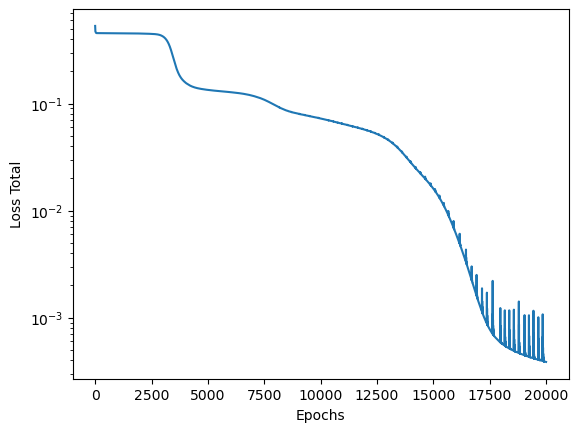

In [10]:
plt.plot(loss_t_list)
plt.ylabel("Loss Total")
plt.xlabel("Epochs")
plt.yscale('log')

# PINN with Neuralevolution

The 5 best among the population
MSE: 0.4546504020690918, neurons in it layer: 20, number of hidden layers 3
MSE: 0.45614635944366455, neurons in it layer: 12, number of hidden layers 5
MSE: 0.45614635944366455, neurons in it layer: 12, number of hidden layers 5
MSE: 0.45683327317237854, neurons in it layer: 8, number of hidden layers 5
MSE: 0.45756521821022034, neurons in it layer: 16, number of hidden layers 8
The best configuration
MSE: 0.15826740860939026, neurons in it layer: 18, number of layers 9


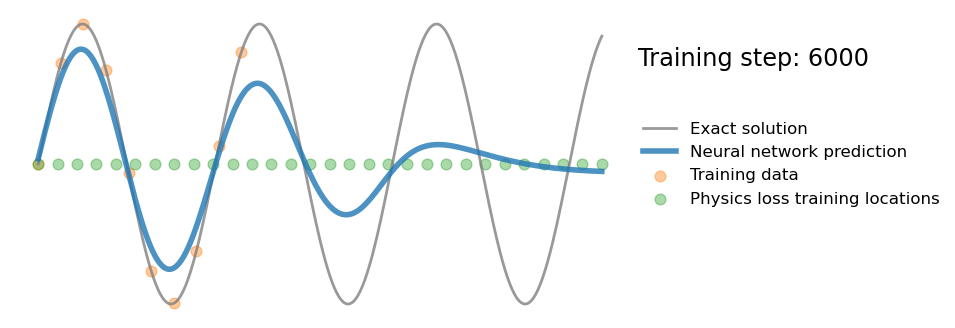

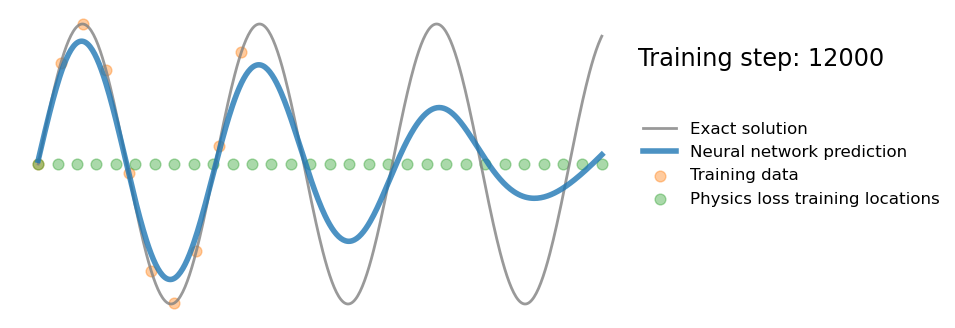

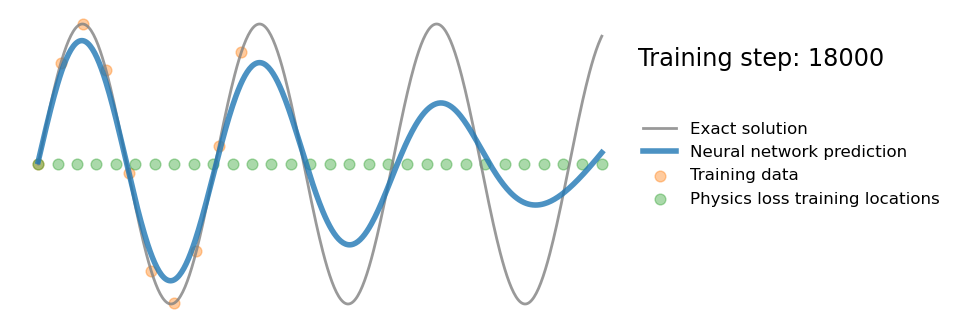

In [24]:
neural = neural_evolution(n_arq=10, ini_epoch=1000, mut_epoch=2000, n_hidden=20, n_layers=10, w0=w0, x_data=x_data, y_data=y_data)

# Training the best configuration
torch.manual_seed(123)
model = FCN(1,1,neural[0],neural[1])
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
files = []
loss1_list = []
loss2_list = []
loss_evo_t_list = []
for i in range(20000):
    optimizer.zero_grad()
    
    # compute the "data loss"
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)# use mean squared error
    
    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
    loss2 = (1e-4)*torch.mean(physics**2)
    
    # backpropagate joint loss
    loss1_list.append(loss1.detach())
    loss2_list.append(loss2.detach())
    loss = loss1 + loss2# add two loss terms together
    loss_evo_t_list.append(loss.detach())
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 150 == 0: 
        
        yh = model(x).detach()
        xp = x_physics.detach()
        
        plot_result(x,y,x_data,y_data,yh,xp)
        
        file = "plots/pinn_neural_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        
        if (i+1) % 6000 == 0: plt.show()
        else: plt.close("all")
            
save_gif_PIL("pinn_neural.gif", files, fps=20, loop=0)


# Comparation between the two PINN

In [27]:
d = {'PINN without NeuroEvolution' : loss_t_list, 'PINN with NeuroEvolution': loss_evo_t_list}
loss_comparation = pd.DataFrame(data=d)

loss_comparation['Dif'] = loss_comparation['PINN without NeuroEvolution'] - loss_comparation['PINN with NeuroEvolution']
print(loss_comparation)

# Mean of the dif

mean_dif = loss_comparation['Dif'].mean()
print(f"The mean value of the difference between the PINN without and with Neuroevolution: {mean_dif}")

      PINN without NeuroEvolution PINN with NeuroEvolution              Dif
0                  tensor(0.4603)           tensor(0.5054)  tensor(-0.0451)
1                  tensor(0.4598)           tensor(0.5013)  tensor(-0.0414)
2                  tensor(0.4595)           tensor(0.4973)  tensor(-0.0379)
3                  tensor(0.4592)           tensor(0.4936)  tensor(-0.0344)
4                  tensor(0.4589)           tensor(0.4901)  tensor(-0.0311)
...                           ...                      ...              ...
19995              tensor(0.0689)           tensor(0.0722)  tensor(-0.0033)
19996              tensor(0.0689)           tensor(0.0722)  tensor(-0.0033)
19997              tensor(0.0689)           tensor(0.0722)  tensor(-0.0033)
19998              tensor(0.0689)           tensor(0.0722)  tensor(-0.0033)
19999              tensor(0.0689)           tensor(0.0722)  tensor(-0.0033)

[20000 rows x 3 columns]
The mean value of the difference between the PINN without and 

Text(0.5, 0, 'Epochs')

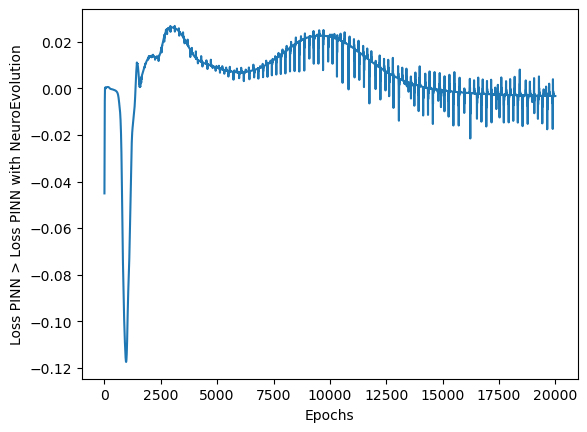

In [ ]:
plt.plot(loss_comparation['Dif'])
plt.ylabel("Loss PINN > Loss PINN with NeuroEvolution")
plt.xlabel("Epochs")

# Running the test 35 times and showing the results

In [69]:
x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain
k = w0**2
    

def NormalRandomPINN(n_hidden=20, n_layers=10, w0=w0, x_data=x_data, y_data=y_data, x_physics=x_physics, folder_path=''):
    # train standard neural network to fit training data
    
    list_n_hidden = np.arange(1, n_hidden+1)
    list_n_layers = np.arange(2, n_layers+1)
    
    c_n_hidden = int(np.random.choice(list_n_hidden))
    c_n_layers = int(np.random.choice(list_n_layers))
    arq = [c_n_hidden, c_n_layers]
    
    arqs = f'layers: {c_n_layers}, Hidden: {c_n_hidden}'
    
    torch.manual_seed(123)
    model = FCN(1,1,c_n_hidden,c_n_layers)
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
    
    loss1_list = []
    loss2_list = []
    loss_t_list = []
    losses = []
    
    for i in range(20000):
        optimizer.zero_grad()
        
        # compute the "data loss"
        yh = model(x_data)
        loss1 = torch.mean((yh-y_data)**2)# use mean squared error
        
        # compute the "physics loss"
        yhp = model(x_physics)
        dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
        dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
        physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
        loss2 = (1e-4)*torch.mean(physics**2)
        
        # backpropagate joint loss
        loss1_list.append(loss1.detach())
        loss2_list.append(loss2.detach())
        loss = loss1 + loss2# add two loss terms together
        loss_t_list.append(loss.detach())
        
        losses.append(loss.detach().numpy().astype(float))
        
        loss.backward()
        optimizer.step()
    
    creating_csv_file(folder_path=folder_path, file_name='Normal', arqs=arqs, loss_data=losses)
        
    return arq, loss_t_list



def NeuroPINN(n_arq=10, ini_epoch=1000, mut_epoch=2000, n_hidden=20, n_layers=10, w0=w0, x_data=x_data, y_data=y_data, folder_path=''):
    
    neural = neural_evolution(n_arq=n_arq, ini_epoch=ini_epoch, mut_epoch=mut_epoch, n_hidden=n_hidden, n_layers=n_layers, w0=w0, x_data=x_data, y_data=y_data,folder_path=folder_path)


    arq = [int(neural[0]), int(neural[1])]
    
    arqs = f"layers: {int(neural[0])}, Hidden: {int(neural[1])}"
    
    
    # Training the best configuration
    torch.manual_seed(123)
    model = FCN(1,1,neural[0],neural[1])
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

    loss1_list = []
    loss2_list = []
    loss_evo_t_list = []
    for i in range(20000):
        optimizer.zero_grad()
        
        # compute the "data loss"
        yh = model(x_data)
        loss1 = torch.mean((yh-y_data)**2)# use mean squared error
        
        # compute the "physics loss"
        yhp = model(x_physics)
        dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
        dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
        physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
        loss2 = (1e-4)*torch.mean(physics**2)
        
        # backpropagate joint loss
        loss1_list.append(loss1.detach())
        loss2_list.append(loss2.detach())
        loss = loss1 + loss2# add two loss terms together
        loss_evo_t_list.append(loss.detach())
        loss.backward()
        optimizer.step()
        
    creating_csv_file(folder_path=folder_path, file_name='Neuro', arqs=arqs, loss_data=loss_evo_t_list)
    
    return arq, loss_evo_t_list

def RunningTest(n=1, n_arq=10, ini_epoch=1000, mut_epoch=2000, n_hidden=20, n_layers=10, w0=w0, x_data=x_data, y_data=y_data, x_physics=x_physics):
    
    x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain
    k = w0**2

    results = []
    
    
    for test in range(0,n):
        
        # Creating a folder for each logs
        folder_path = f'logs/{test}'
        try:
            os.makedirs(folder_path, exist_ok=True)
            print(f"Folder '{folder_path}' ensured to exist.")
        except OSError as e:
            print(f"Error creating folder: {e}")
        
        
        normal_arq, loss_t_list = NormalRandomPINN(n_hidden=n_hidden, n_layers=n_layers, w0=w0, x_data=x_data, y_data=y_data, x_physics=x_physics, folder_path=folder_path)
        
        
        evo_arq, loss_evo_t_list = NeuroPINN(n_arq=n_arq, ini_epoch=ini_epoch, mut_epoch=mut_epoch, n_hidden=n_hidden, n_layers=n_layers, w0=w0, x_data=x_data, y_data=y_data, folder_path=folder_path)
        
        d = {'PINN without NeuroEvolution' : loss_t_list, 'PINN with NeuroEvolution': loss_evo_t_list}
        loss_comparation = pd.DataFrame(data=d)

        loss_comparation['Dif'] = loss_comparation['PINN without NeuroEvolution'] - loss_comparation['PINN with NeuroEvolution']

        # Mean of the dif
        mean_dif = loss_comparation['Dif'].mean()
        
        str_list1 = f'Layers: {normal_arq[0]} | Neurons per layer: {normal_arq[1]}'
        str_list2 = f'Layers: {evo_arq[0]} | Neurons per layer: {evo_arq[1]}'
        
        d_input = {'PINN without NeuroEvolution architecture' : str_list1,
                   'PINN with NeuroEvolution architecture': str_list2,
                   'Mean difference between the loss functions' : mean_dif}

        results.append(d_input)
        

    results = pd.DataFrame(results)
                
        
    
    return results


results = RunningTest(n=1, n_arq=10, ini_epoch=1000, mut_epoch=2000, n_hidden=20, n_layers=10, w0=w0, x_data=x_data, y_data=y_data, x_physics=x_physics)

results


Folder 'logs/0' ensured to exist.
<class 'list'>
[array(1.06946409), array(1.06577754), array(1.06210041), array(1.05843318), array(1.05477619), array(1.05112958), array(1.04749346), array(1.04386795), array(1.04025328), array(1.03664947), array(1.03305686), array(1.02947545), array(1.02590561), array(1.02234733), array(1.01880085), array(1.01526618), array(1.01174355), array(1.00823319), array(1.00473511), array(1.00124943), array(0.99777609), array(0.99431551), array(0.99086761), array(0.98743242), array(0.98401022), array(0.98060095), array(0.9772048), array(0.97382182), array(0.97045189), array(0.96709532), array(0.96375203), array(0.96042216), array(0.95710576), array(0.95380282), array(0.95051336), array(0.94723749), array(0.94397533), array(0.94072676), array(0.93749201), array(0.93427098), array(0.93106365), array(0.92787004), array(0.92469013), array(0.92152405), array(0.91837168), array(0.91523314), array(0.91210848), array(0.90899765), array(0.9059006), array(0.90281749), ar

,PINN without NeuroEvolution architecture,PINN with NeuroEvolution architecture,Mean difference between the loss functions
0,Layers: 5 | Neurons per layer: 5,Layers: 17 | Neurons per layer: 9,0.28063


## PINN Discovery (Desenvolvendo ainda)

In [13]:
# x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain


# torch.manual_seed(123)
# model = FCN(1,1,32,3)
# optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
# files = []
# loss1_list = []
# loss2_list = []
# loss_t_list = []
# for i in range(20000):
#     optimizer.zero_grad()
#     # compute the "data loss"
#     yh = model(x_data)
#     loss1 = torch.mean((yh-y_data)**2)# use mean squared error
#     k = model(k)
#     # compute the "physics loss"
#     yhp = model(x_physics)
#     dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
#     dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
#     physics = dx2 + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
#     loss2 = (1e-4)*torch.mean(physics**2)
    
#     # backpropagate joint loss
#     loss1_list.append(loss1.detach())
#     loss2_list.append(loss2.detach())
#     loss = loss1 + loss2# add two loss terms together
#     loss_t_list.append(loss.detach())
#     loss.backward()
#     optimizer.step()
    
    
#     # plot the result as training progresses
#     if (i+1) % 150 == 0: 
        
#         yh = model(x).detach()
#         xp = x_physics.detach()
        
#         plot_result(x,y,x_data,y_data,yh,xp)
        
#         file = "plots/pinn_disc_%.8i.png"%(i+1)
#         plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
#         files.append(file)
        
#         if (i+1) % 6000 == 0: plt.show()
#         else: plt.close("all")
            
# save_gif_PIL("pinn_disc.gif", files, fps=20, loop=0)

In [4]:
df = pd.DataFrame({'Name': ['Alice', 'Bob'], 'Age': [25, 30]})

# New row data as a dictionary
new_row_data = {'Name': 'Charlie', 'Age': 35}

# Convert dictionary to a DataFrame
new_row_df = pd.DataFrame([new_row_data])

# Concatenate the original DataFrame and the new row DataFrame
# ignore_index=True resets the index of the resulting DataFrame
df = pd.concat([df, new_row_df], ignore_index=True)

print(df)

      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   35


In [16]:
import pandas as pd

# Collect data in a list of dictionaries
data_to_add = []
for i in range(5):
    new_data = {'A': i, 'B': i * 2}
    data_to_add.append(new_data)

# Create the DataFrame once from the collected list
new_df = pd.DataFrame(data_to_add)

# If starting with an existing DataFrame, concatenate at the end
# df = pd.concat([original_df, new_df], ignore_index=True)

print(new_df)

   A  B
0  0  0
1  1  2
2  2  4
3  3  6
4  4  8


In [5]:
for n in range(0,35):
    folder_path = f'logs/{n}'
    try:
        os.makedirs(folder_path, exist_ok=True)
        print(f"Folder '{folder_path}' ensured to exist.")
    except OSError as e:
        print(f"Error creating folder: {e}")


Folder 'logs/0' ensured to exist.
Folder 'logs/1' ensured to exist.
Folder 'logs/2' ensured to exist.
Folder 'logs/3' ensured to exist.
Folder 'logs/4' ensured to exist.
Folder 'logs/5' ensured to exist.
Folder 'logs/6' ensured to exist.
Folder 'logs/7' ensured to exist.
Folder 'logs/8' ensured to exist.
Folder 'logs/9' ensured to exist.
Folder 'logs/10' ensured to exist.
Folder 'logs/11' ensured to exist.
Folder 'logs/12' ensured to exist.
Folder 'logs/13' ensured to exist.
Folder 'logs/14' ensured to exist.
Folder 'logs/15' ensured to exist.
Folder 'logs/16' ensured to exist.
Folder 'logs/17' ensured to exist.
Folder 'logs/18' ensured to exist.
Folder 'logs/19' ensured to exist.
Folder 'logs/20' ensured to exist.
Folder 'logs/21' ensured to exist.
Folder 'logs/22' ensured to exist.
Folder 'logs/23' ensured to exist.
Folder 'logs/24' ensured to exist.
Folder 'logs/25' ensured to exist.
Folder 'logs/26' ensured to exist.
Folder 'logs/27' ensured to exist.
Folder 'logs/28' ensured to ex

In [62]:
lista_dados = [[1,2,3,4],[5,6,7,8]]
dados3 = [9,10,11,12]

lista_dados.append(dados3)
print(lista_dados)

arq = 'arq1'
lista_dados = dados3

# arq = ['arq1', 'arq2', 'arq3']

if type(arq) == list:
    dict_dados = dict(zip(arq, lista_dados))
else:
    dict_dados = {arq : dados3}

print(dict_dados)
data_frame = pd.DataFrame(data=dict_dados)

# data_frame.to_csv('logs/0/test.csv', index=False, sep=',')

[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]]
{'arq1': [9, 10, 11, 12]}
